# Inferencia final con YOLO sobre imágenes completas

En esta sección se evalúan los modelos entrenados con parches originales y denoised. La inferencia se realiza sobre imágenes completas del conjunto de test, dividiéndolas dinámicamente en parches y aplicando un filtrado de duplicados. Las detecciones resultantes se evalúan frente al ground truth mediante solapamiento (IoU ≥ 0,5), obteniendo precisión y recall por página.

## 1. Carga de rutas, modelos y parámetros

In [2]:
from pathlib import Path
from ultralytics import YOLO


# ORIGINAL

ruta_test_original = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_original/images/test")
ruta_labels_original = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_original/labels/test")
ruta_modelo_original = "/home/salvarado/TFM/resultados/result_yolo/parches_originales_1024_50ep-2/weights/best.pt"

modelo_original = YOLO(ruta_modelo_original)
print("Modelo original 1024 cargado")


# DENOISED

ruta_test_denoised = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_denoised/images/test")
ruta_labels_denoised = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_denoised/labels/test")
ruta_modelo_denoised = "/home/salvarado/TFM/resultados/result_yolo/parches_denoised_1024_50ep/weights/best.pt"

modelo_denoised = YOLO(ruta_modelo_denoised)
print("Modelo denoised 1024 cargado")


Modelo original 1024 cargado
Modelo denoised 1024 cargado


## Definicion de parametros de inferencia

In [3]:

patch_size = 2048
overlap = 512
step = patch_size - overlap

conf = 0.5
imgsz = 1024

print("Parámetros listos")
print("Patch size:", patch_size)
print("Overlap:", overlap)
print("Step:", step)
print("Conf:", conf)
print("imgsz:", imgsz)

Parámetros listos
Patch size: 2048
Overlap: 512
Step: 1536
Conf: 0.5
imgsz: 1024


In [4]:
def calcular_iou(caja1, caja2):
    """Calcula el IoU entre dos cajas [x1, y1, x2, y2]."""
    x1 = max(caja1[0], caja2[0])
    y1 = max(caja1[1], caja2[1])
    x2 = min(caja1[2], caja2[2])
    y2 = min(caja1[3], caja2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    interseccion = inter_w * inter_h

    area1 = (caja1[2] - caja1[0]) * (caja1[3] - caja1[1])
    area2 = (caja2[2] - caja2[0]) * (caja2[3] - caja2[1])
    union = area1 + area2 - interseccion

    return interseccion / union if union > 0 else 0


def evaluar_deteccion(reales, detectadas, umbral_iou=0.5):
    """
    Empareja detecciones con cajas reales por IoU.
    reales, detectadas: listas de [x1, y1, x2, y2]
    Devuelve: TP, FP, FN
    """
    reales_usadas = [False] * len(reales)
    tp = 0
    fp = 0

    for caja_det in detectadas:
        mejor_iou = 0
        mejor_idx = -1
        for i, caja_real in enumerate(reales):
            if reales_usadas[i]:
                continue
            iou = calcular_iou(caja_det, caja_real)
            if iou > mejor_iou:
                mejor_iou = iou
                mejor_idx = i

        if mejor_iou >= umbral_iou:
            tp += 1
            reales_usadas[mejor_idx] = True
        else:
            fp += 1

    fn = reales_usadas.count(False)
    return tp, fp, fn

print("Funciones de evaluación por IoU cargadas")

Funciones de evaluación por IoU cargadas


## 3. Inferencia con modelo original 1024

En esta sección se realiza la inferencia sobre las imágenes completas originales del conjunto de test. Cada imagen se divide dinámicamente en parches, el modelo realiza predicciones sobre cada parche y posteriormente se aplica un filtro para eliminar detecciones duplicadas generadas por el solapamiento entre parches.

RESULTADOS ORIGINAL 1024
Imagen                           Reales     TP     FP     FN  Precisión   Recall
-------------------------------------------------------------------------------------
sakuma-0447_Page_02                 152    143      3      9      0.979    0.941
sakuma-0451_Page_26                 323    321      1      2      0.997    0.994
sakuma-0469_Page_09                 259    254     12      5      0.955    0.981
sakuma-0469_Page_13                 229    215      8     14      0.964    0.939
sakuma-0470_Page_07                 260    257      3      3      0.988    0.988
sakuma-0513_Page_03                 100     90      5     10      0.947    0.900
sakuma-0513_Page_06                 321    312     14      9      0.957    0.972
sakuma-0581_Page_12                 237    231      4      6      0.983    0.975
sakuma-0581_Page_19                 250    238      8     12      0.967    0.952
sakuma-0581_Page_29                 129    125      2      4      0.984    0.96

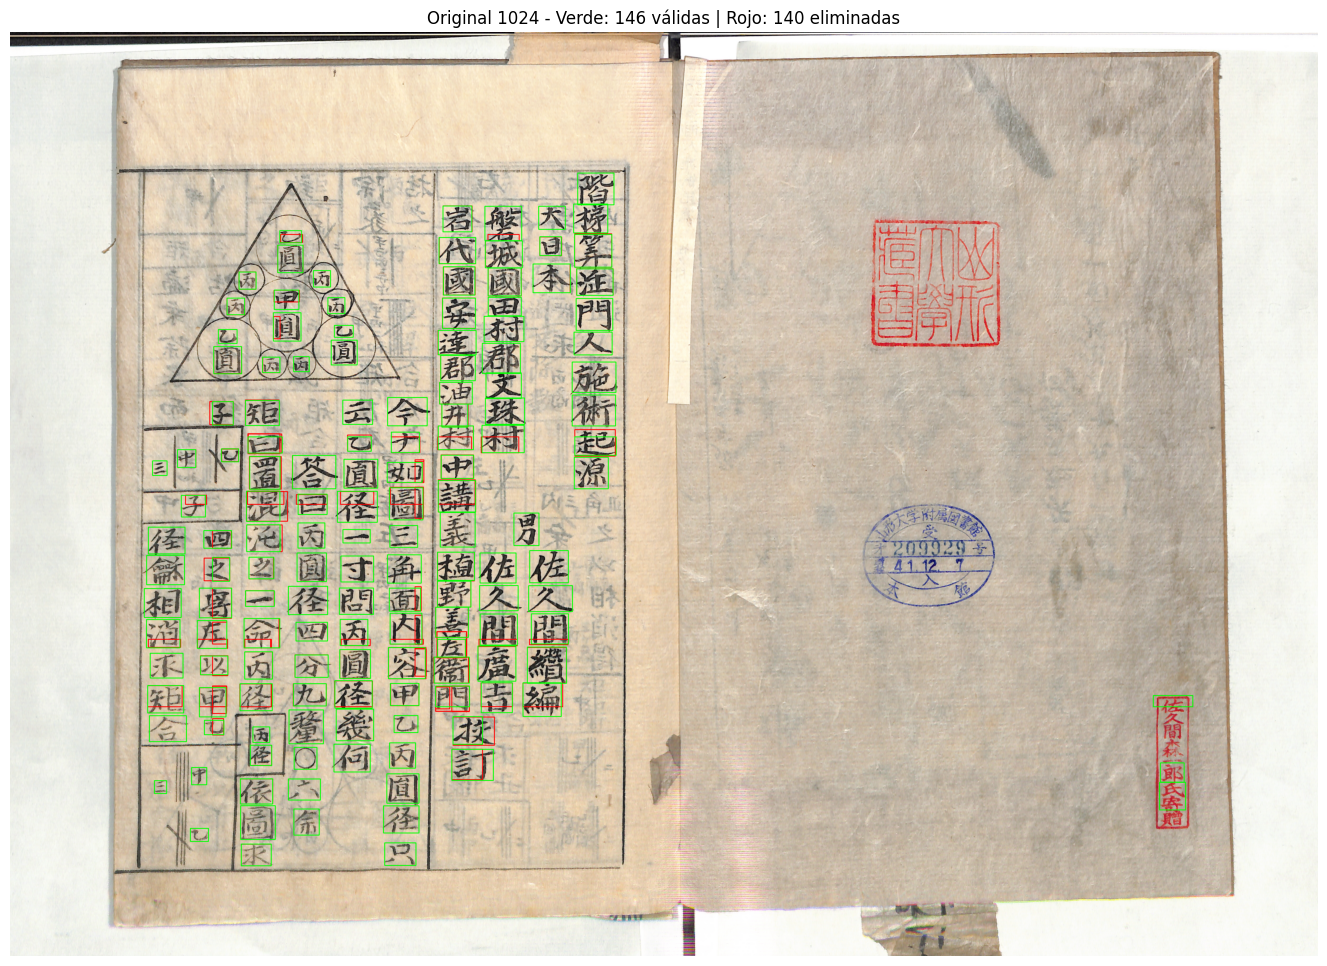

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2, glob, os

test_paths = sorted(glob.glob(str(ruta_test_original) + "/*.png"))

print("RESULTADOS ORIGINAL 1024")
print(f"{'Imagen':<30} {'Reales':>8} {'TP':>6} {'FP':>6} {'FN':>6} {'Precisión':>10} {'Recall':>8}")
print("-" * 85)

resultados_original = []

imagen_visual = None
buenas_visual = None
eliminadas_visual = None

for img_path in test_paths:
    imagen = cv2.imread(img_path)
    alto, ancho = imagen.shape[:2]
    nombre = os.path.basename(img_path).replace(".png", "")

    # Cargar cajas reales (coordenadas, no solo el conteo)
    label_path = str(ruta_labels_original / (nombre + ".txt"))
    reales = []
    with open(label_path) as f:
        for linea in f:
            datos = linea.split()
            cx = float(datos[1]) * ancho
            cy = float(datos[2]) * alto
            bw = float(datos[3]) * ancho
            bh = float(datos[4]) * alto
            reales.append([cx - bw/2, cy - bh/2, cx + bw/2, cy + bh/2])
    n_reales = len(reales)

    # Detectar en parches
    todas_cajas = []

    for y in range(0, alto, step):
        for x in range(0, ancho, step):
            parche = imagen[y:y+patch_size, x:x+patch_size]

            if parche.shape[0] < 1000 or parche.shape[1] < 1000:
                continue

            res = modelo_original.predict(
                source=parche,
                conf=conf,
                imgsz=imgsz,
                device=0,
                verbose=False
            )

            for box in res[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                todas_cajas.append([x1+x, y1+y, x2+x, y2+y, float(box.conf[0])])

    # Filtrar duplicados
    cajas_ordenadas = sorted(todas_cajas, key=lambda c: c[4], reverse=True)

    buenas = []
    eliminadas = []

    for caja in cajas_ordenadas:
        duplicada = False

        for guardada in buenas:
            x1 = max(caja[0], guardada[0])
            y1 = max(caja[1], guardada[1])
            x2 = min(caja[2], guardada[2])
            y2 = min(caja[3], guardada[3])

            inter = max(0, x2-x1) * max(0, y2-y1)

            area_caja = (caja[2]-caja[0]) * (caja[3]-caja[1])
            area_guardada = (guardada[2]-guardada[0]) * (guardada[3]-guardada[1])
            area_menor = min(area_caja, area_guardada)

            if area_menor > 0 and inter / area_menor > 0.5:
                duplicada = True
                break

        if duplicada:
            eliminadas.append(caja)
        else:
            buenas.append(caja)

    # Evaluación por IoU contra el ground truth
    detectadas = [c[:4] for c in buenas]  # quitar la confianza, dejar solo xyxy
    tp, fp, fn = evaluar_deteccion(reales, detectadas, umbral_iou=0.5)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    resultados_original.append({
        "imagen": nombre,
        "reales": n_reales,
        "sin_filtro": len(todas_cajas),
        "con_filtro": len(buenas),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": round(precision, 3),
        "recall": round(recall, 3)
    })

    print(f"{nombre:<30} {n_reales:>8} {tp:>6} {fp:>6} {fn:>6} {precision:>10.3f} {recall:>8.3f}")

    # Guardar una imagen para visualizar el filtro
    if imagen_visual is None:
        imagen_visual = imagen
        buenas_visual = buenas
        eliminadas_visual = eliminadas
        nombre_visual = nombre

# Visualización del filtro
dibujo = imagen_visual.copy()

for x1, y1, x2, y2, c in eliminadas_visual:
    cv2.rectangle(dibujo, (x1, y1), (x2, y2), (0, 0, 255), 6)

for x1, y1, x2, y2, c in buenas_visual:
    cv2.rectangle(dibujo, (x1, y1), (x2, y2), (0, 255, 0), 6)

plt.figure(figsize=(18, 12))
plt.imshow(cv2.cvtColor(dibujo, cv2.COLOR_BGR2RGB))
plt.title(f"Original 1024 - Verde: {len(buenas_visual)} válidas | Rojo: {len(eliminadas_visual)} eliminadas")
plt.axis("off")
plt.show()

In [8]:
print("Tabla 6.6: Detecciones con pipeline de parches, sin filtro de duplicados (original)")
print(f"{'Imagen':<30} {'Reales':>8} {'Sin filtro':>12}")
print("-" * 55)

for r in resultados_original:
    print(f"{r['imagen']:<30} {r['reales']:>8} {r['sin_filtro']:>12}")

Tabla 6.6: Detecciones con pipeline de parches, sin filtro de duplicados (original)
Imagen                           Reales   Sin filtro
-------------------------------------------------------
sakuma-0447_Page_02                 152          286
sakuma-0451_Page_26                 323          569
sakuma-0469_Page_09                 259          532
sakuma-0469_Page_13                 229          361
sakuma-0470_Page_07                 260          433
sakuma-0513_Page_03                 100          165
sakuma-0513_Page_06                 321          582
sakuma-0581_Page_12                 237          445
sakuma-0581_Page_19                 250          418
sakuma-0581_Page_29                 129          218


 ## DENOISED: inferencia con y sin filtro

RESULTADOS DENOISED 1024
Imagen                           Reales     TP     FP     FN  Precisión   Recall
-------------------------------------------------------------------------------------
sakuma-0447_Page_02denoised         152    144     11      8      0.929    0.947
sakuma-0451_Page_26denoised         323    312      5     11      0.984    0.966
sakuma-0469_Page_09denoised         259    250     12      9      0.954    0.965
sakuma-0469_Page_13denoised         229    215      8     14      0.964    0.939
sakuma-0470_Page_07denoised         260    256      3      4      0.988    0.985
sakuma-0513_Page_03denoised         100     90      0     10      1.000    0.900
sakuma-0513_Page_06denoised         321    310     15     11      0.954    0.966
sakuma-0581_Page_12denoised         237    231      3      6      0.987    0.975
sakuma-0581_Page_19denoised         250    233      5     17      0.979    0.932
sakuma-0581_Page_29denoised         129    121      2      8      0.984    0.93

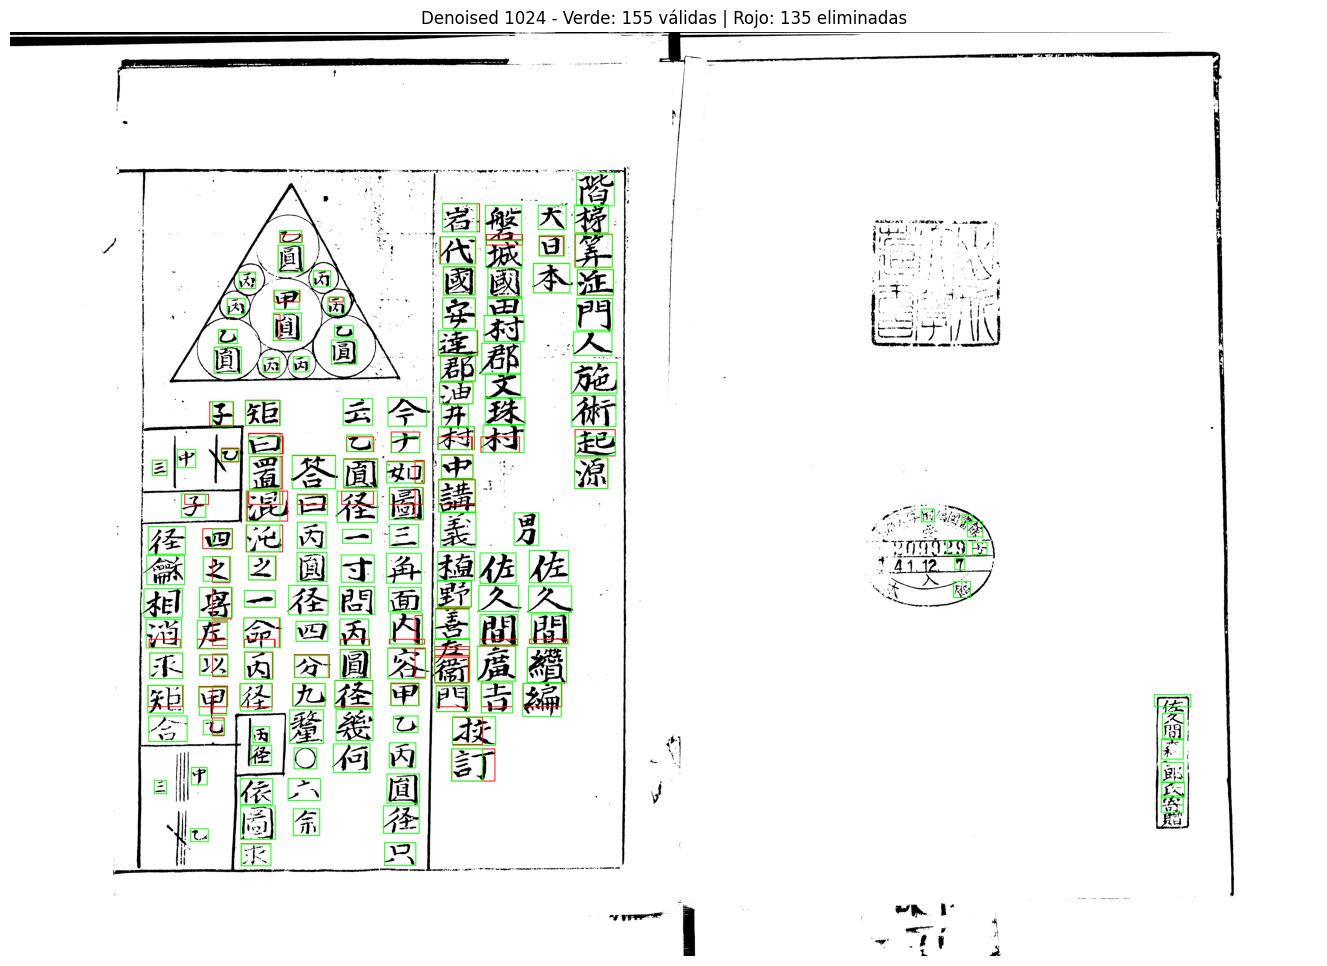

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2, glob, os

test_paths = sorted(glob.glob(str(ruta_test_denoised) + "/*.png"))

print("RESULTADOS DENOISED 1024")
print(f"{'Imagen':<30} {'Reales':>8} {'TP':>6} {'FP':>6} {'FN':>6} {'Precisión':>10} {'Recall':>8}")
print("-" * 85)

resultados_denoised = []

imagen_visual = None
buenas_visual = None
eliminadas_visual = None

for img_path in test_paths:
    imagen = cv2.imread(img_path)
    alto, ancho = imagen.shape[:2]
    nombre = os.path.basename(img_path).replace(".png", "")

    # Cargar cajas reales (coordenadas, no solo el conteo)
    label_path = str(ruta_labels_denoised / (nombre + ".txt"))
    reales = []
    with open(label_path) as f:
        for linea in f:
            datos = linea.split()
            cx = float(datos[1]) * ancho
            cy = float(datos[2]) * alto
            bw = float(datos[3]) * ancho
            bh = float(datos[4]) * alto
            reales.append([cx - bw/2, cy - bh/2, cx + bw/2, cy + bh/2])
    n_reales = len(reales)

    # Detectar en parches
    todas_cajas = []

    for y in range(0, alto, step):
        for x in range(0, ancho, step):
            parche = imagen[y:y+patch_size, x:x+patch_size]

            if parche.shape[0] < 1000 or parche.shape[1] < 1000:
                continue

            res = modelo_denoised.predict(
                source=parche,
                conf=conf,
                imgsz=imgsz,
                device=0,
                verbose=False
            )

            for box in res[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                todas_cajas.append([x1+x, y1+y, x2+x, y2+y, float(box.conf[0])])

    # Filtrar duplicados
    cajas_ordenadas = sorted(todas_cajas, key=lambda c: c[4], reverse=True)

    buenas = []
    eliminadas = []

    for caja in cajas_ordenadas:
        duplicada = False

        for guardada in buenas:
            x1 = max(caja[0], guardada[0])
            y1 = max(caja[1], guardada[1])
            x2 = min(caja[2], guardada[2])
            y2 = min(caja[3], guardada[3])

            inter = max(0, x2-x1) * max(0, y2-y1)

            area_caja = (caja[2]-caja[0]) * (caja[3]-caja[1])
            area_guardada = (guardada[2]-guardada[0]) * (guardada[3]-guardada[1])
            area_menor = min(area_caja, area_guardada)

            if area_menor > 0 and inter / area_menor > 0.5:
                duplicada = True
                break

        if duplicada:
            eliminadas.append(caja)
        else:
            buenas.append(caja)

    # Evaluación por IoU contra el ground truth
    detectadas = [c[:4] for c in buenas]
    tp, fp, fn = evaluar_deteccion(reales, detectadas, umbral_iou=0.5)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    resultados_denoised.append({
        "imagen": nombre,
        "reales": n_reales,
        "sin_filtro": len(todas_cajas),
        "con_filtro": len(buenas),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": round(precision, 3),
        "recall": round(recall, 3)
    })

    print(f"{nombre:<30} {n_reales:>8} {tp:>6} {fp:>6} {fn:>6} {precision:>10.3f} {recall:>8.3f}")

    # Guardar una imagen para visualizar el filtro
    if imagen_visual is None:
        imagen_visual = imagen
        buenas_visual = buenas
        eliminadas_visual = eliminadas
        nombre_visual = nombre

# Visualización del filtro
dibujo = imagen_visual.copy()

for x1, y1, x2, y2, c in eliminadas_visual:
    cv2.rectangle(dibujo, (x1, y1), (x2, y2), (0, 0, 255), 6)

for x1, y1, x2, y2, c in buenas_visual:
    cv2.rectangle(dibujo, (x1, y1), (x2, y2), (0, 255, 0), 6)

plt.figure(figsize=(18, 12))
plt.imshow(cv2.cvtColor(dibujo, cv2.COLOR_BGR2RGB))
plt.title(f"Denoised 1024 - Verde: {len(buenas_visual)} válidas | Rojo: {len(eliminadas_visual)} eliminadas")
plt.axis("off")
plt.show()

In [7]:
print("COMPARACIÓN FINAL: ORIGINAL VS DENOISED")
print(f"{'Imagen':<30} {'Reales':>8} {'Prec.O':>8} {'Rec.O':>8} {'Prec.D':>8} {'Rec.D':>8}")
print("-" * 80)

for orig, den in zip(resultados_original, resultados_denoised):
    nombre = orig["imagen"].replace("denoised", "")

    print(
        f"{nombre:<30} "
        f"{orig['reales']:>8} "
        f"{orig['precision']:>8.3f} "
        f"{orig['recall']:>8.3f} "
        f"{den['precision']:>8.3f} "
        f"{den['recall']:>8.3f}"
    )

COMPARACIÓN FINAL: ORIGINAL VS DENOISED
Imagen                           Reales   Prec.O    Rec.O   Prec.D    Rec.D
--------------------------------------------------------------------------------
sakuma-0447_Page_02                 152    0.979    0.941    0.929    0.947
sakuma-0451_Page_26                 323    0.997    0.994    0.984    0.966
sakuma-0469_Page_09                 259    0.955    0.981    0.954    0.965
sakuma-0469_Page_13                 229    0.964    0.939    0.964    0.939
sakuma-0470_Page_07                 260    0.988    0.988    0.988    0.985
sakuma-0513_Page_03                 100    0.947    0.900    1.000    0.900
sakuma-0513_Page_06                 321    0.957    0.972    0.954    0.966
sakuma-0581_Page_12                 237    0.983    0.975    0.987    0.975
sakuma-0581_Page_19                 250    0.967    0.952    0.979    0.932
sakuma-0581_Page_29                 129    0.984    0.969    0.984    0.938


## Análisis final

Los resultados confirman que el pipeline de inferencia con parches (apartado 5.2) y el filtro de eliminación de duplicados (apartado 5.3) funcionan correctamente.

Con el pipeline completo, YOLO obtiene una precisión y un recall altos y estables en las diez páginas de test, tanto en el dataset original (precisión entre 0,947 y 0,997; recall entre 0,900 y 0,994) como en el denoised (precisión entre 0,929 y 1,000; recall entre 0,900 y 0,985). Las diferencias entre ambos datasets son pequeñas, sin que ninguno de los dos sea claramente mejor que el otro.

Comparado con la imagen completa sin pipeline (apartado 6.5.1), donde la precisión estaba entre 0,852 y 1,000 y el recall entre 0,624 y 0,940, el pipeline completo mejora sobre todo el recall, y lo hace mucho más estable entre páginas.